# Non Specular Model

In [397]:
from PyMoosh.classes import *
from PyMoosh.core import *
from PyMoosh.non_spec import *
import matplotlib.pyplot as plt 
import numpy as np

wavelength = 100
struct = Structure([1.,1.9,1.45],[0,1,2,0],[7000, 2000, 600,200])
window = Window(400*wavelength, 0.3, 30., 30.)
beam = Beam(wavelength, (50)*np.pi/180, 0, 5*wavelength)

List of materials:
Simple, non dispersive: epsilon= (1+0j)
Simple, non dispersive: epsilon= (1.9+0j)
Simple, non dispersive: epsilon= (1.45+0j)
Pixels horizontally: 1333
Incidence in degrees: 50.0
E//, TE, s polarization


## A bit of explications:
In wave optics, the standard refraction is not anymore acruate. Indeed, by a multiple factor of interferences and intern propagations in the matter, we get that in the cas of difraction, the behavior of the electromagnetic wave slidely changes. One of these changes can be see through the study of the outcoming beam. We can see that it has a shifting value and an elargment value wich mean it can has a greater or a lower width and center of energy is not coming from the same point as the incoming beam.

---

## Maths:
We have the different formulas to compute these values, 1st the exact expressions and 2nd, the asymptotic ones.



1 - Analytic expressions:

For the shift, considering the surface of the structure parallel to the x axe, and since the center of mass is defined as $\frac{\int x|H|^{2} dx}{\int |H|^{2} dx}$, the shift, here is simply a difference between the center of mass of the incident beam and the reflected beam. We get 

$\delta = \frac{\int x|H_{r}|^{2} dx}{\int |H_{r}|^{2} dx} - \frac{\int x|H_{i}|^{2} dx}{\int |H_{i}|^{2} dx}$

For the enlargement, we must use a standard deviation calculation like, giving the "width" of the beam. It gives $\frac{\int x^{2}|H|^{2} dx}{\int |H|^{2} dx}$. Following the previous logic, the enlargement is 

$\Delta = \frac{\int (x - \delta)^{2}|H_{r}|^{2} dx}{\int |H_{r}|^{2} dx} - \frac{\int x^{2}|H_{i}|^{2} dx}{\int |H_{i}|^{2} dx}$. 

WARNING: it assumes that incident beam is centred in 0, if it is not the case we must shift the center of x. We finaly get the expression 

$\Delta = \frac{\int (x - (x_{m} + \delta))^{2}|H_{r}|^{2} dx}{\int |H_{r}|^{2} dx} - \frac{\int (x - x_{m})^{2}|H_{i}|^{2} dx}{\int |H_{i}|^{2} dx}$ 

where $x_{m}$ is the center of mass of the incident beam, $x_{m} = \frac{\int x|H_{i}|^{2} dx}{\int |H_{i}|^{2} dx}$. This is what does the function `deltas(struct, beam, window)`



2 - Asymptotic expressions:

Using limit calculation and development, when the waist of the gaussian beam $w \rightarrow \infty$ we get the shift:

$\delta = -\phi'$ 

and the enlargement:

$\Delta = \frac{1}{2}(\frac{\rho'^{2}}{\rho^{2}} - \frac{\rho''}{\rho})$ 

where $\phi$ is the phase and $\rho$ the module, both of the reflection coefficient, " ' " means the derivative over $k_{x}$. Because we use the incidence angle $\theta$ to configure our beam, it will be useful to change these derivatives in a expression with $\theta$ rather than $k_{x}$.

Because $k_{x} = nk_{0}sin(\theta)$, we get 

$\frac{d}{dk_{x}} = \frac{1}{nk_{0}cos(\theta)}\frac{d}{d\theta}$ 

with $k_{0} = \frac{2\pi}{\lambda}$, $\lambda$ is the wavelength and $n = \sqrt{\epsilon}$, $\epsilon$ is the effective permittivity felt by the electromagnetic wave.

We also need the second derivative:

$\frac{d^{2}}{dk_{x}^{2}} = \frac{1}{nk_{0}cos(\theta)}\frac{d}{d\theta}(\frac{1}{nk_{0}cos(\theta)}\frac{d}{d\theta})$

Which leads to:

$\frac{d^{2}}{dk_{x}^{2}} = \frac{1}{(nk_{0}cos(\theta))^{2}}\frac{d^{2}}{d\theta^{2}} + \frac{sin(\theta)}{(nk_{0})^{2}cos(\theta)^{3}}\frac{d}{d\theta}$

To simplify, we introduce the parameter $c_{\alpha} = nk_{0}cos(\theta)$. At the end we get

$\delta = \frac{1}{c_{\alpha}}\frac{d\phi}{d\theta}$

and 

$\Delta = \frac{1}{2}(\frac{(\frac{d\rho}{d\theta})^{2}}{(c_{\alpha}\rho)^{2}} - \frac{\frac{d\rho^{2}}{d\theta^{2}} + tan(\theta)\frac{d\rho}{d\theta}}{c_{\alpha}^{2}\rho})$ 

This is what does the function `asymptcoef(struct, beam)`

## Examples:

---

### Modification of the function "field":

Aiming to isolate the reflected and the incident field, a new parameter has been had to the function field. By default this parameter has no value (`None`) but if we turn it `True` it will automatically isolate the reflected field and at the end we will only get the reflected field. At the opposite, if we turn it `False` it will only gives us the incident field.

Full field first, only the reflected field in second and only transmitted field at the end:

Pixels vertically: 325
Pixels vertically: 325
Pixels vertically: 325


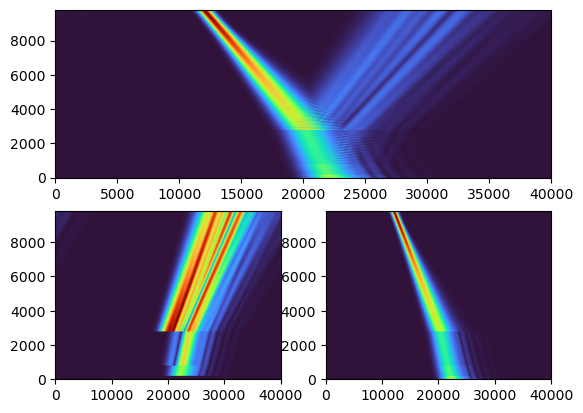

In [398]:
plt.subplot(211)
E = field(struct, beam, window)
plt.imshow(abs(E),cmap='turbo',extent=[0,window.width,0,sum(struct.thickness)],aspect='auto')

plt.subplot(223)
E = field(struct, beam, window, True)
plt.imshow(abs(E),cmap='turbo',extent=[0,window.width,0,sum(struct.thickness)],aspect='auto')

plt.subplot(224)
E = field(struct, beam, window, False)
plt.imshow(abs(E),cmap='turbo',extent=[0,window.width,0,sum(struct.thickness)],aspect='auto')

plt.show()

### Modification of the class "Beam":

Since PyMoosh uses a gaussian beam, the waist defined the "minimum of width" of the beam but previously, it was defined at the top of the simulation window. Now a new parameter allows the user to chose the distance from the top of the window where is located the waste. Once again it is an optional parameter (0 by default) and by default the distance is in nanometer.

At first, no modification, in second the waist is in the middle of the first layer (before the first interface), third it is inside the structure and at the end it is above the simulation window:

List of materials:
Simple, non dispersive: epsilon= (1+0j)
Simple, non dispersive: epsilon= (2.25+0j)
Incidence in degrees: 50.0
E//, TE, s polarization
Pixels vertically: 299
Incidence in degrees: 50.0
E//, TE, s polarization
Pixels vertically: 299
Incidence in degrees: 50.0
E//, TE, s polarization
Pixels vertically: 299
Incidence in degrees: 50.0
E//, TE, s polarization
Pixels vertically: 299


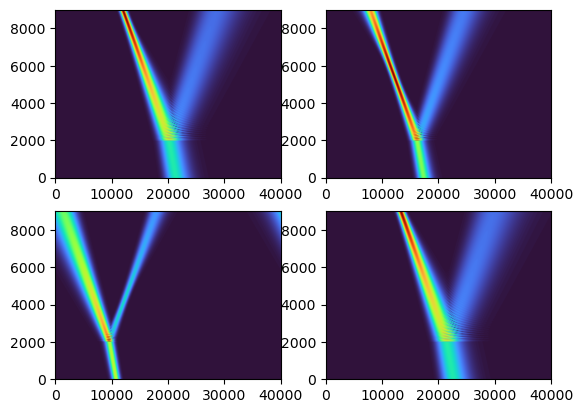

In [399]:
# To make i easier we simplify the structure
struct = Structure([1.,2.25],[0,1],[7000, 2000])

plt.subplot(221)
beam = Beam(wavelength, (50)*np.pi/180, 0, 5*wavelength)
E = field(struct, beam, window)
plt.imshow(abs(E),cmap='turbo',extent=[0,window.width,0,sum(struct.thickness)],aspect='auto')

plt.subplot(222)
beam = Beam(wavelength, (50)*np.pi/180, 0, 5*wavelength, 3500)
E = field(struct, beam, window)
plt.imshow(abs(E),cmap='turbo',extent=[0,window.width,0,sum(struct.thickness)],aspect='auto')

plt.subplot(223)
beam = Beam(wavelength, (50)*np.pi/180, 0, 5*wavelength, 9000)
E = field(struct, beam, window)
plt.imshow(abs(E),cmap='turbo',extent=[0,window.width,0,sum(struct.thickness)],aspect='auto')

plt.subplot(224)
beam = Beam(wavelength, (50)*np.pi/180, 0, 5*wavelength, -1000)
E = field(struct, beam, window)
plt.imshow(abs(E),cmap='turbo',extent=[0,window.width,0,sum(struct.thickness)],aspect='auto')

plt.show()

An interesting point is that when the distance get inside (or beyond) the structure, it seems that the reflected beam converge before to diverge again (its waist is above the structure)

### Plot of the field profile at the interface:

In order to study properly the field at the interface, it is useful to isolate the field amplitude here. This is what are made for the `profil(struct, beam, window)` (& co) function(s). It compute the field thanks to the function `field` then isolate the first interface of the structure and get the field profil here. There is an extra  parameter which allows the user to get the total field rather than the amplitude. For that, just add nothing else than `"abs"` in last argument.

1 - Incident + reflected beam

2 - Incident beam only

3 - Reflected beam only

List of materials:
Simple, non dispersive: epsilon= (1+0j)
Simple, non dispersive: epsilon= (1.9+0j)
Simple, non dispersive: epsilon= (1.45+0j)


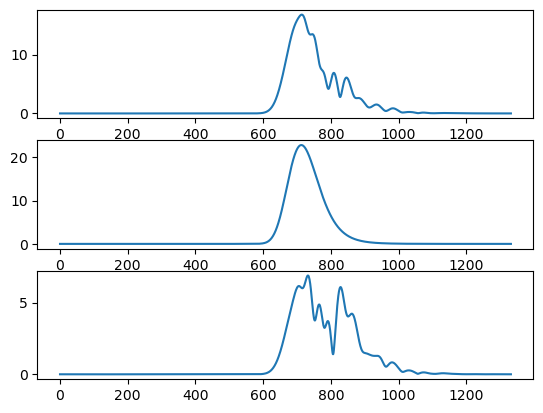

In [400]:
struct = Structure([1.,1.9,1.45],[0,1,2,0],[7000, 2000, 600,200])

plt.subplot(311)
Prof_tot = profil_tot(struct, beam, window)
plt.plot(Prof_tot)

plt.subplot(312)
Prof_in = profil_In(struct, beam, window)
plt.plot(Prof_in)

plt.subplot(313)
Prof_r = profil_R(struct, beam, window)
plt.plot(Prof_r)

plt.show()

### Functions `deltas(struct, beam, window)` and `asymptcoef(struct, beam)`:

Using the maths explained above and the previous functions, based on the simulation result, the function `deltas` compute the shift $\delta$ and the enlargement $\Delta$.
For `asymptcoef` we use the function `coefficient_S` from PyMoosh to determined the reflection coefficient. Then it is based on numerical derivative. Since it is an asymptotic development the value doesn't change when the waist is changed.

The most important point here is that when the waist is big enough, `deltas` $\approx$ `asymptcoef`.

Because the window is periodic, it is important to pay attention to the relative size of the window compare to the beam and the incident angle (see illustration in the next code session)

Mesured values for the waist of 5:
 shift =  1330.7588636867476   enlargement =  2978684.540395961 
Asymptotic values:
 shift =  -230.89252375560997   enlargement =  24626635.095163073
Pixels horizontally: 16666
Incidence in degrees: 50.0
E//, TE, s polarization
Mesured values for the waist of 500:
 shift =  -184.74527141803992   enlargement =  24220852.861145735 
Asymptotic values:
 shift =  -230.89252375560997   enlargement =  24626635.095163073
Pixels horizontally: 5000
Mesured values with the wrong window size:
 shift =  -100.46077047853032   enlargement =  14719571.104430676 
Asymptotic values:
 shift =  -230.89252375560997   enlargement =  24626635.095163073
Pixels vertically: 325
Pixels horizontally: 16666
Pixels vertically: 325


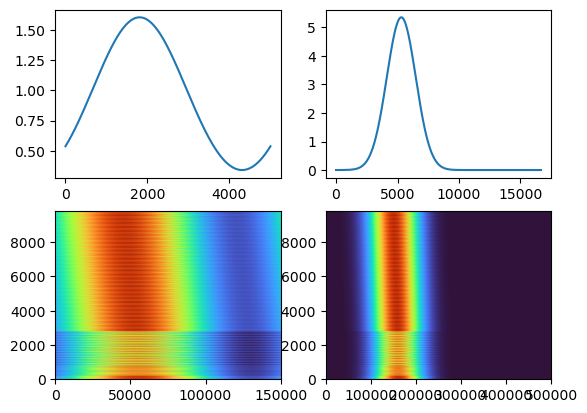

In [401]:
# For waist of 5:
lims = asymptcoef(struct, beam)
delt = deltas(struct, beam, window, False)
print("Mesured values for the waist of 5:\n", "shift = ", delt[0], "  enlargement = ", delt[1], "\nAsymptotic values:\n","shift = ", lims[0], "  enlargement = ",lims[1])

# For waist of 500:
window = Window(5000*wavelength, 0.3, 30., 30.)
beam = Beam(wavelength, (50)*np.pi/180, 0, 500*wavelength)
lims = asymptcoef(struct, beam)
delt = deltas(struct, beam, window, False)
print("Mesured values for the waist of 500:\n", "shift = ", delt[0], "  enlargement = ", delt[1], "\nAsymptotic values:\n","shift = ", lims[0], "  enlargement = ",lims[1])

# It is important to improve the window size in consequence or their might get interferences between left and right side which will end with false results:
# Exemple:
window = Window(1500*wavelength, 0.3, 30., 30.)

delt = deltas(struct, beam, window, False)
print("Mesured values with the wrong window size:\n", "shift = ", delt[0], "  enlargement = ", delt[1], "\nAsymptotic values:\n","shift = ", lims[0], "  enlargement = ",lims[1])

plt.subplot(221)
Prof_tot = profil_tot(struct, beam, window)
plt.plot(Prof_tot)

plt.subplot(223)
E = field(struct, beam, window)
plt.imshow(abs(E),cmap='turbo',extent=[0,window.width,0,sum(struct.thickness)],aspect='auto')


# Correct one:
window = Window(5000*wavelength, 0.3, 30., 30.)

plt.subplot(222)
Prof_tot = profil_tot(struct, beam, window)
plt.plot(Prof_tot)

plt.subplot(224)
E = field(struct, beam, window)
plt.imshow(abs(E),cmap='turbo',extent=[0,window.width,0,sum(struct.thickness)],aspect='auto')

plt.show()


### The evolution of the shift in function of the angle:

The interesting point here is that there is some "resonance" angles for which ones the shift (and the enlargement) goes crazy in the simulation, the pic in the asymptotic computing shows the total refraction angle. Studying a bit these cases for the simulation shows us it can be related to vanishing waves present in resonance mods. If we manually suppressed the vanishing waves, the curve goes back to "normal".

Pixels horizontally: 3333
Incidence in degrees: 40.0
E//, TE, s polarization
Incidence in degrees: 40.1
E//, TE, s polarization
Incidence in degrees: 40.2
E//, TE, s polarization
Incidence in degrees: 40.300000000000004
E//, TE, s polarization
Incidence in degrees: 40.400000000000006
E//, TE, s polarization
Incidence in degrees: 40.50000000000001
E//, TE, s polarization
Incidence in degrees: 40.60000000000001
E//, TE, s polarization
Incidence in degrees: 40.70000000000001
E//, TE, s polarization
Incidence in degrees: 40.80000000000001
E//, TE, s polarization
Incidence in degrees: 40.90000000000001
E//, TE, s polarization
Incidence in degrees: 41.000000000000014
E//, TE, s polarization
Incidence in degrees: 41.10000000000002
E//, TE, s polarization
Incidence in degrees: 41.20000000000002
E//, TE, s polarization
Incidence in degrees: 41.30000000000002
E//, TE, s polarization
Incidence in degrees: 41.40000000000002
E//, TE, s polarization
Incidence in degrees: 41.50000000000002
E//, TE, s

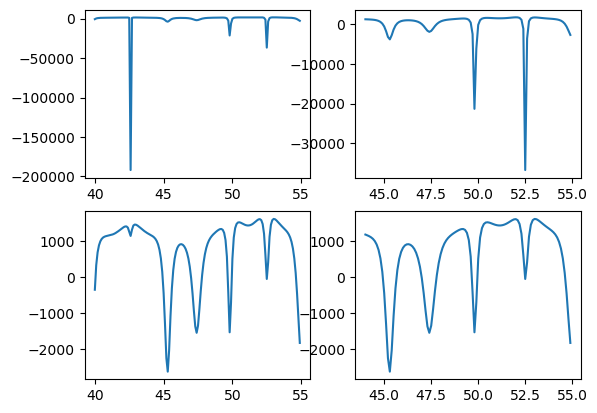

In [402]:

window = Window(1000*wavelength, 0.3, 30., 30.)
P = []
L = []
A = Theta = np.arange(40, 55, 1/10)

for i in A:
    beam = Beam(wavelength, i*np.pi/180, 0, 100*wavelength)
    P.append(deltas(struct, beam, window, False)[0])
    L.append(asymptcoef(struct, beam)[0])
    
plt.subplot(221)
plt.plot(A, L)

plt.subplot(223)
plt.plot(A, P)

plt.subplot(222)
plt.plot(A[40:], L[40:])

plt.subplot(224)
plt.plot(A[40:], P[40:])

plt.show()


Now, let make a complex mapping of the phase of the reflection coefficient and the derivative of the phase:

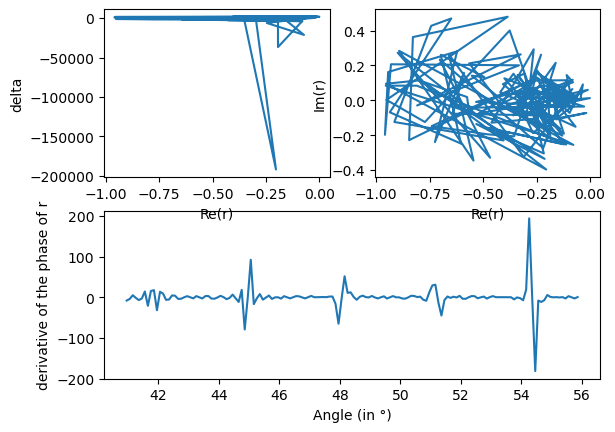

n*K0 =  (0.06283185307179587+0j)


In [403]:
x = []
y = []
phi = []
for i in A:
    r = coefficient_S(struct, wavelength, (beam.incidence + i), 0)[0]
    x.append(np.real(r))
    y.append(np.imag(r))
    phi.append(np.angle(r)/np.sin(i)) #since nk0 is a constant, it does not affect the shape of the curve
z = L

plt.subplot(212)
plt.plot(np.ones(len(A))*beam.incidence + A, np.gradient(phi))
plt.xlabel("Angle (in °)")
plt.ylabel("derivative of the phase of r")

plt.subplot(221)
plt.plot(x, z)
plt.xlabel("Re(r)")
plt.ylabel("delta")

plt.subplot(222)
plt.plot(x,y)
plt.xlabel("Re(r)")
plt.ylabel("Im(r)")

plt.show()
print("n*K0 = ",np.sqrt(struct.materials[0].permittivity)*np.pi*2/wavelength)


When the waist is too small, not only the asymptotic approximation is not longer correct but resonances are dominant and all we see is vanishing waves traces:

Pixels horizontally: 666
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.1
E//, TE, s polarization
Incidence in degrees: 25.200000000000003
E//, TE, s polarization
Incidence in degrees: 25.300000000000004
E//, TE, s polarization
Incidence in degrees: 25.40000000000001
E//, TE, s polarization
Incidence in degrees: 25.500000000000007
E//, TE, s polarization
Incidence in degrees: 25.60000000000001
E//, TE, s polarization
Incidence in degrees: 25.70000000000001
E//, TE, s polarization
Incidence in degrees: 25.80000000000001
E//, TE, s polarization
Incidence in degrees: 25.90000000000001
E//, TE, s polarization
Incidence in degrees: 26.000000000000014
E//, TE, s polarization
Incidence in degrees: 26.100000000000016
E//, TE, s polarization
Incidence in degrees: 26.200000000000017
E//, TE, s polarization
Incidence in degrees: 26.30000000000002
E//, TE, s polarization
Incidence in degrees: 26.400000000000016
E//, TE, s polarization
Incidence in degrees: 26.500000000

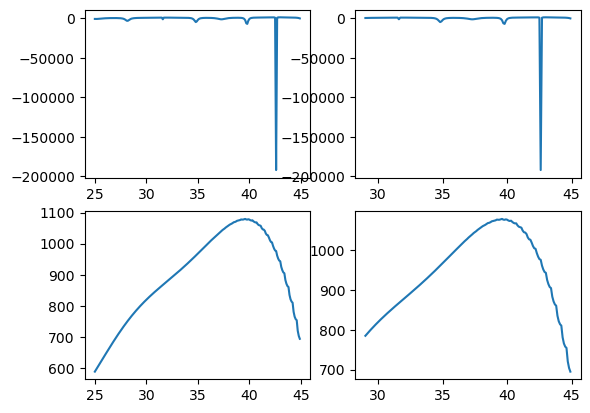

In [404]:

window = Window(200*wavelength, 0.3, 30., 30.) # Reduce the window to save computing time
P = []
L = []
A = Theta = np.arange(25, 45, 1/10)

for i in A:
    beam = Beam(wavelength, i*np.pi/180, 0, 2*wavelength)
    P.append(deltas(struct, beam, window, False)[0])
    L.append(asymptcoef(struct, beam)[0])
    
plt.subplot(221)
plt.plot(A, L)

plt.subplot(223)
plt.plot(A, P)

plt.subplot(222)
plt.plot(A[40:], L[40:])

plt.subplot(224)
plt.plot(A[40:], P[40:])
plt.show()

Changing the wavelength will affect the curves (a bit) but a small waist will amplify these changes.

Wavelength:

1 - 200 nm

2 - 600 nm

3 - 1000 nm

4 - 1200 nm

Pixels horizontally: 3333
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.1
E//, TE, s polarization
Incidence in degrees: 25.1
E//, TE, s polarization
Incidence in degrees: 25.1
E//, TE, s polarization
Incidence in degrees: 25.1
E//, TE, s polarization
Incidence in degrees: 25.200000000000003
E//, TE, s polarization
Incidence in degrees: 25.200000000000003
E//, TE, s polarization
Incidence in degrees: 25.200000000000003
E//, TE, s polarization
Incidence in degrees: 25.200000000000003
E//, TE, s polarization
Incidence in degrees: 25.300000000000004
E//, TE, s polarization
Incidence in degrees: 25.300000000000004
E//, TE, s polarization
Incidence in degrees: 25.300000000000004
E//, TE, s polarization
Incidence in degrees: 25.300000000000004
E//, TE, s polarization
Incidence in degrees: 25.40000000000001
E//, T

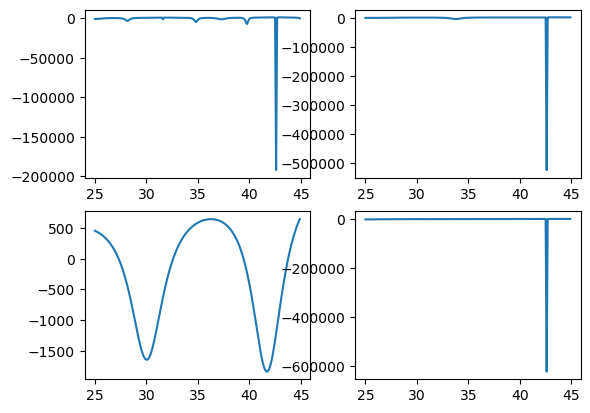

In [405]:
# For time issue this cell will only compare the asymptotic values
P = []
L = []
M = []
O = []

window = Window(1000*wavelength, 0.3, 30., 30.) 


for i in A:
    beam = Beam(wavelength, i*np.pi/180, 0, 50*wavelength)
    L.append(asymptcoef(struct, beam)[0])
    
    beam = Beam(3*wavelength, i*np.pi/180, 0, 50*wavelength)
    O.append(asymptcoef(struct, beam)[0])
    
    beam = Beam(5*wavelength, i*np.pi/180, 0, 50*wavelength)
    M.append(asymptcoef(struct, beam)[0])
    
    beam = Beam(6*wavelength, i*np.pi/180, 0, 50*wavelength)
    P.append(asymptcoef(struct, beam)[0])


plt.subplot(221)
plt.plot(A, L)

plt.subplot(222)
plt.plot(A, O)

plt.subplot(223)
plt.plot(A, M)

plt.subplot(224)
plt.plot(A, P)


Changing the layer thicknesses will clearly influence the behavior of the field:

List of materials:
Simple, non dispersive: epsilon= (1+0j)
Simple, non dispersive: epsilon= (3+0j)
Simple, non dispersive: epsilon= (5+0j)
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.1
E//, TE, s polarization
Incidence in degrees: 25.200000000000003
E//, TE, s polarization
Incidence in degrees: 25.300000000000004
E//, TE, s polarization
Incidence in degrees: 25.40000000000001
E//, TE, s polarization
Incidence in degrees: 25.500000000000007
E//, TE, s polarization
Incidence in degrees: 25.60000000000001
E//, TE, s polarization
Incidence in degrees: 25.70000000000001
E//, TE, s polarization
Incidence in degrees: 25.80000000000001
E//, TE, s polarization
Incidence in degrees: 25.90000000000001
E//, TE, s polarization
Incidence in degrees: 26.000000000000014
E//, TE, s polarization
Incidence in degrees: 26.100000000000016
E//, TE, s polarization
Incidence in degrees: 26.200000000000017
E//, TE, s polarization
Incidence in degrees: 26.30000000000002
E//, TE, 

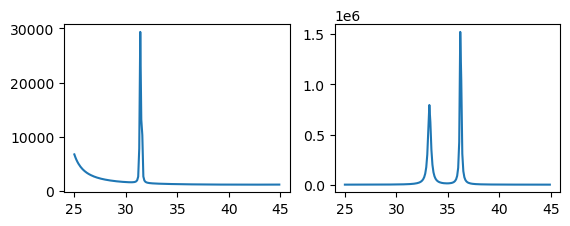

In [406]:
# For time issue this cell will only compare the asymptotic values
P = []
L = []
M = []
O = []

wavelength = 2000
struct = Structure([1.,3,5], [2,0,1,0,1,0],[2*wavelength, wavelength, 0.5*wavelength, wavelength, 0.5*wavelength, wavelength])
for i in A:
    beam = Beam(wavelength, i*np.pi/180, 0, 50*wavelength)
    L.append(asymptcoef(struct, beam)[0])

for i in A:
    beam = Beam(3*wavelength, i*np.pi/180, 0, 50*wavelength)
    O.append(asymptcoef(struct, beam)[0])

plt.subplot(221)
plt.plot(A, L)

plt.subplot(222)
plt.plot(A, O)


beam = Beam(wavelength, 50*np.pi/180, 0, 50*wavelength)

Some useful application of these functions:
Here we will find the optimal waist for a determined angle in order to get the maximum relative shift.

Pixels horizontally: 73333
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Incidence in degrees: 25.0
E//, TE, s polarization
Inci

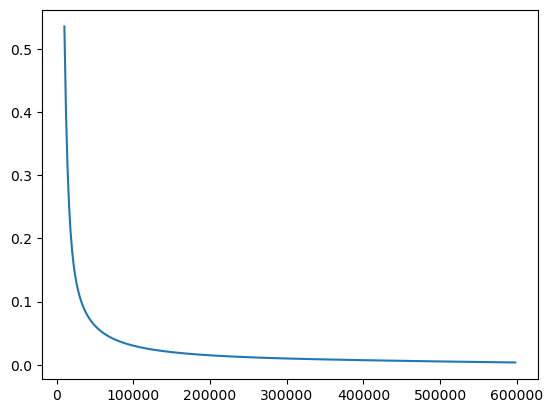

In [ ]:



angle = 25

best = 0
worst = 0
max = -10000000
min = 10000000
window = Window(1100*wavelength, 0.3, 30., 30.) 
P = []
W = np.arange(5, 300, 1)
for i in W:
    beam = Beam(wavelength, angle*np.pi/180, 0, i*wavelength)
    shift = deltas(struct, beam, window)[0]
    P.append(shift)
    if max < shift:
        max = shift
        best = i*wavelength
    if min > shift:
        worst = i*wavelength
        min = shift

print("Optimal waist: ",best, "\nWorst waist: ", worst)
plt.plot(W*wavelength,P)
plt.show()


If we compare different waists, we clearly see the difference between the relative shifts:

List of materials:
Simple, non dispersive: epsilon= (1+0j)
Simple, non dispersive: epsilon= (3+0j)
Simple, non dispersive: epsilon= (5+0j)
Pixels horizontally: 133333
Incidence in degrees: 33.85000000000001
H//, TM, p polarization
Pixels vertically: 279


IndexError: index 6 is out of bounds for axis 0 with size 6

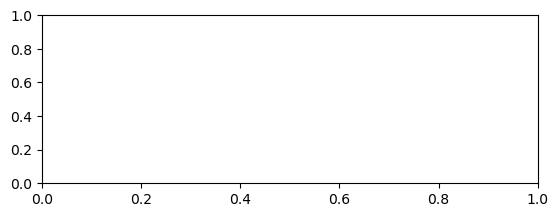

In [ ]:
angle = 33.85
struct = Structure([1.,3.,5.], [2,0,1,0,1,0],[wavelength, 0.65*wavelength,  0.28539*wavelength, (1)*wavelength, 0.28539*wavelength, wavelength])

window = Window(2000*wavelength, .1, 30., 30.)
beam = Beam(wavelength, angle*np.pi/180, 1, 50*wavelength)

plt.subplot(211)
plt.imshow(np.abs(field(struct, beam, window)), cmap='turbo',extent=[0,window.width,0,sum(struct.thickness)],aspect='auto')

plt.subplot(212)
plt.plot(profil_In(struct, beam, window))
plt.plot(profil_R(struct, beam, window))

